In [ ]:
# ============================================================================
# YOLOv11 Instance Segmentation Training - FIXED
# Auto GPU Detection + Resume Functionality
# 100 Epochs (Sufficient for ~2000 images)
# ============================================================================

import os
import sys
import yaml
import torch
import shutil
from pathlib import Path
from datetime import datetime
import json
import numpy as np

# ============================================================================
# STEP 1: FIX GOOGLE COLAB GPU (CRITICAL!)
# ============================================================================

print("=" * 70)
print("🔧 FIXING GOOGLE COLAB GPU SETUP")
print("=" * 70)

# Check if running in Colab
try:
    import google.colab
    IN_COLAB = True
    print("✅ Running in Google Colab")
except:
    IN_COLAB = False
    print("ℹ️ Not running in Colab")

# Install CUDA-compatible PyTorch if needed
if IN_COLAB and not torch.cuda.is_available():
    print("\n⚠️ CUDA not available - reinstalling PyTorch...")
    print("   This may take 2-3 minutes...\n")

    import subprocess
    subprocess.run([
        sys.executable, "-m", "pip", "uninstall", "-y", "torch", "torchvision", "torchaudio"
    ], capture_output=True)

    subprocess.run([
        sys.executable, "-m", "pip", "install", "-q",
        "torch", "torchvision", "torchaudio", "--index-url",
        "https://download.pytorch.org/whl/cu118"
    ], check=True)

    # Reload torch
    import importlib
    importlib.reload(torch)

    print("✅ PyTorch reinstalled with CUDA support\n")

# Verify CUDA
print("\n🖥️ GPU CHECK:")
print(f"   CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"   GPU: {torch.cuda.get_device_name(0)}")
    print(f"   CUDA version: {torch.version.cuda}")
    print(f"   Device count: {torch.cuda.device_count()}")
    DEVICE = '0'
else:
    print("   ⚠️ No GPU - will use CPU (VERY SLOW!)")
    print("   💡 In Colab: Runtime → Change runtime type → GPU (T4)")
    DEVICE = 'cpu'

print()

# ============================================================================
# STEP 2: INSTALL DEPENDENCIES
# ============================================================================

print("=" * 70)
print("📦 INSTALLING DEPENDENCIES")
print("=" * 70)

import subprocess
subprocess.run([
    sys.executable, "-m", "pip", "install", "-q", "--upgrade",
    "ultralytics>=8.3.0",
    "roboflow",
], check=True)

print("✅ Dependencies installed\n")

from ultralytics import YOLO
from roboflow import Roboflow

# ============================================================================
# CONFIGURATION (100 EPOCHS - SUFFICIENT!)
# ============================================================================

class Config:
    # Dataset
    roboflow_api_key = "Enter_API_Key"
    roboflow_workspace = "emtechieee"
    roboflow_project = "oil-xzcql"
    roboflow_version = 2

    # Model (YOLOv11m-seg for best accuracy + 30+ FPS)
    model_size = "yolo11m-seg"

    # Training (100 epochs is ENOUGH for ~2000 images!)
    epochs = 100  # ✅ REDUCED FROM 200
    patience = 25  # Early stopping
    batch_size = 16  # Reduce to 8 if OOM
    imgsz = 640

    # Optimizer
    optimizer = "AdamW"
    lr0 = 0.001
    lrf = 0.01
    weight_decay = 0.0005
    warmup_epochs = 3.0

    # Augmentation
    hsv_h = 0.015
    hsv_s = 0.7
    hsv_v = 0.4
    degrees = 0.0
    flipud = 0.0
    fliplr = 0.5
    mosaic = 1.0

    # Hardware (AUTO-DETECTED)
    device = DEVICE  # Auto: '0' or 'cpu'
    workers = 2 if DEVICE == 'cpu' else 8
    amp = True if DEVICE != 'cpu' else False

    # Output
    project = "runs/segment"
    name = f"oil_yolo11m_{datetime.now().strftime('%Y%m%d_%H%M')}"
    resume = True  # ✅ AUTO-RESUME

cfg = Config()

# ============================================================================
# DOWNLOAD DATASET
# ============================================================================

print("=" * 70)
print("📥 DOWNLOADING DATASET")
print("=" * 70)

rf = Roboflow(api_key=cfg.roboflow_api_key)
workspace = rf.workspace(cfg.roboflow_workspace)
project = workspace.project(cfg.roboflow_project)
version = project.version(cfg.roboflow_version)

dataset = version.download("yolov11")
DATASET_PATH = dataset.location
DATA_YAML = f"{DATASET_PATH}/data.yaml"

print(f"✅ Dataset: {DATASET_PATH}")
print(f"✅ Config: {DATA_YAML}\n")

# Verify
with open(DATA_YAML, 'r') as f:
    data_config = yaml.safe_load(f)

print(f"📊 Classes: {data_config['names']}")

def count_images(path):
    if not os.path.exists(path):
        return 0
    return len([f for f in os.listdir(path) if f.endswith(('.jpg', '.png'))])

train_count = count_images(f"{DATASET_PATH}/train/images")
val_count = count_images(f"{DATASET_PATH}/valid/images")

print(f"📊 Train: {train_count} | Valid: {val_count}\n")

# ============================================================================
# CHECK FOR RESUME
# ============================================================================

print("=" * 70)
print("🔄 CHECKING FOR CHECKPOINTS")
print("=" * 70)

# Find latest run
runs_dir = Path(cfg.project)
if runs_dir.exists():
    existing_runs = sorted([d for d in runs_dir.iterdir() if d.is_dir() and d.name.startswith('oil_')])
    if existing_runs:
        latest_run = existing_runs[-1]
        last_checkpoint = latest_run / "weights" / "last.pt"

        if last_checkpoint.exists() and cfg.resume:
            print(f"✅ Found checkpoint: {last_checkpoint}")
            print("   Will RESUME from this checkpoint\n")
            RESUME_FROM = str(last_checkpoint)
        else:
            print("ℹ️ No valid checkpoint found\n")
            RESUME_FROM = False
    else:
        print("ℹ️ No previous runs found\n")
        RESUME_FROM = False
else:
    print("ℹ️ First training run\n")
    RESUME_FROM = False

# ============================================================================
# INITIALIZE MODEL
# ============================================================================

print("=" * 70)
print("🏗️ MODEL INITIALIZATION")
print("=" * 70)

if RESUME_FROM:
    print(f"Loading checkpoint: {RESUME_FROM}")
    model = YOLO(RESUME_FROM)
else:
    print(f"Loading pretrained: {cfg.model_size}.pt")
    model = YOLO(f"{cfg.model_size}.pt")

print("✅ Model ready\n")

# ============================================================================
# TRAINING
# ============================================================================

print("=" * 70)
print("🚀 STARTING TRAINING")
print("=" * 70)

print(f"""
Configuration:
  Model: {cfg.model_size}
  Epochs: {cfg.epochs} ✅ (100 is enough!)
  Batch: {cfg.batch_size}
  Device: {cfg.device}
  Resume: {bool(RESUME_FROM)}

Dataset:
  Train: {train_count} images
  Valid: {val_count} images
""")

print("=" * 70)
print()

# Train
try:
    results = model.train(
        # Dataset
        data=DATA_YAML,

        # Duration
        epochs=cfg.epochs,
        patience=cfg.patience,

        # Batch & Image
        batch=cfg.batch_size,
        imgsz=cfg.imgsz,

        # Optimizer
        optimizer=cfg.optimizer,
        lr0=cfg.lr0,
        lrf=cfg.lrf,
        weight_decay=cfg.weight_decay,
        warmup_epochs=cfg.warmup_epochs,

        # Augmentation
        hsv_h=cfg.hsv_h,
        hsv_s=cfg.hsv_s,
        hsv_v=cfg.hsv_v,
        degrees=cfg.degrees,
        flipud=cfg.flipud,
        fliplr=cfg.fliplr,
        mosaic=cfg.mosaic,

        # Hardware
        device=cfg.device,
        workers=cfg.workers,
        amp=cfg.amp,

        # Output
        project=cfg.project,
        name=cfg.name,
        resume=RESUME_FROM,

        # Other
        val=True,
        plots=True,
        save=True,
        verbose=True,
    )

except Exception as e:
    print(f"\n❌ Training failed: {e}")
    import traceback
    traceback.print_exc()
    sys.exit(1)

# ============================================================================
# TRAINING COMPLETE
# ============================================================================

print("\n" + "=" * 70)
print("✅ TRAINING COMPLETE!")
print("=" * 70)

# Find weights
weights_dir = Path(cfg.project) / cfg.name / "weights"
best_weights = weights_dir / "best.pt"
last_weights = weights_dir / "last.pt"

print(f"\n📦 Weights saved:")
if best_weights.exists():
    size_mb = best_weights.stat().st_size / (1024 * 1024)
    print(f"   Best: {best_weights} ({size_mb:.1f} MB)")
else:
    print(f"   Best: Not found")

if last_weights.exists():
    size_mb = last_weights.stat().st_size / (1024 * 1024)
    print(f"   Last: {last_weights} ({size_mb:.1f} MB)")

# ============================================================================
# VALIDATION
# ============================================================================

if best_weights.exists():
    print("\n" + "=" * 70)
    print("📊 FINAL VALIDATION")
    print("=" * 70)

    best_model = YOLO(str(best_weights))
    metrics = best_model.val(data=DATA_YAML, split='test')

    print(f"\n🏆 Results:")
    print(f"   Box mAP@0.5: {metrics.box.map50:.4f}")
    print(f"   Mask mAP@0.5: {metrics.seg.map50:.4f}")
    print(f"   Precision: {metrics.box.mp:.4f}")
    print(f"   Recall: {metrics.box.mr:.4f}")

# ============================================================================
# BENCHMARK
# ============================================================================

if best_weights.exists() and torch.cuda.is_available():
    print("\n" + "=" * 70)
    print("⏱️ BENCHMARKING FPS")
    print("=" * 70)

    import time

    benchmark_model = YOLO(str(best_weights))
    dummy = torch.randn(1, 3, 640, 640).cuda()

    # Warmup
    for _ in range(10):
        _ = benchmark_model.predict(dummy, imgsz=640, verbose=False)

    # Benchmark
    times = []
    for _ in range(100):
        torch.cuda.synchronize()
        t0 = time.perf_counter()
        _ = benchmark_model.predict(dummy, imgsz=640, verbose=False)
        torch.cuda.synchronize()
        times.append(time.perf_counter() - t0)

    times = np.array(times) * 1000
    fps = 1000 / times.mean()

    print(f"\n📊 PyTorch FP16:")
    print(f"   Mean: {times.mean():.2f} ms")
    print(f"   FPS: {fps:.1f}")

    if fps >= 30:
        print(f"   ✅ EXCEEDS 30 FPS!")
    else:
        print(f"   ⚠️ Below 30 FPS")
        print(f"   Expected with TensorRT: ~{fps * 1.6:.1f} FPS")

# ============================================================================
# DOWNLOAD INSTRUCTIONS
# ============================================================================

print("\n" + "=" * 70)
print("💾 DOWNLOAD WEIGHTS")
print("=" * 70)

if IN_COLAB and best_weights.exists():
    print("""
To download in Google Colab:

```python
from google.colab import files
files.download('""" + str(best_weights) + """')
```

Or mount Google Drive:
```python
from google.colab import drive
drive.mount('/content/drive')

import shutil
shutil.copy('""" + str(best_weights) + """',
            '/content/drive/MyDrive/')
```
""")

print("\n" + "=" * 70)
print("🎉 DONE!")
print("=" * 70)

print(f"""
Summary:
  Model: YOLOv11m-seg
  Epochs: 100 ✅ (sufficient for your dataset)
  Dataset: {train_count} train, {val_count} valid
  Weights: {best_weights if best_weights.exists() else 'Not found'}

Next Steps:
  1. Download best.pt
  2. Test with inference script
  3. Convert to TensorRT FP16 for 50-70 FPS
  4. Deploy!

Expected Performance (RTX 4050):
  - PyTorch FP16: 35-45 FPS
  - TensorRT FP16: 50-70 FPS ✅
""")

🔧 FIXING GOOGLE COLAB GPU SETUP
✅ Running in Google Colab

🖥️ GPU CHECK:
   CUDA available: True
   GPU: Tesla T4
   CUDA version: 12.8
   Device count: 1

📦 INSTALLING DEPENDENCIES
✅ Dependencies installed

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
📥 DOWNLOADING DATASET
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Oil-2 in yolov11:: 100%|██████████| 1334/1334 [00:00<00:00, 8164.39it/s]


✅ Dataset: /content/Oil-2
✅ Config: /content/Oil-2/data.yaml

📊 Classes: ['Oil Spill']
📊 Train: 460 | Valid: 133

🔄 CHECKING FOR CHECKPOINTS
ℹ️ First training run

🏗️ MODEL INITIALIZATION
Loading pretrained: yolo11m-seg.pt
✅ Model ready

🚀 STARTING TRAINING

Configuration:
  Model: yolo11m-seg
  Epochs: 100 ✅ (100 is enough!)
  Batch: 16
  Device: 0
  Resume: False

Dataset:
  Train: 460 images
  Valid: 133 images


Ultralytics 8.4.21 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Oil-2/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, forma

KeyboardInterrupt: 

In [ ]:
from google.colab import files
import os

print('Please upload your "best.pt" file:')
uploaded = files.upload()

for fn in uploaded.keys():
  print('User uploaded file "{name}" with length {length} bytes'.format(
      name=fn, length=len(uploaded[fn])))

# Set the path for the uploaded weights
UPLOADED_WEIGHTS = list(uploaded.keys())[0]
print(f'\nWeights ready at: {UPLOADED_WEIGHTS}')

Please upload your "best.pt" file:


Saving best_yolo11m.pt to best_yolo11m.pt
User uploaded file "best_yolo11m.pt" with length 40519980 bytes

Weights ready at: best_yolo11m.pt


Ultralytics 8.4.21 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11m summary (fused): 126 layers, 20,030,803 parameters, 0 gradients, 67.6 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1273.9±382.3 MB/s, size: 32.4 KB)
val: Scanning /content/Oil-2/test/labels... 68 images, 36 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 68/68 2.1Kit/s 0.0s
val: New cache created: /content/Oil-2/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 5/5 1.7it/s 2.9s
                   all         68        183      0.877      0.863      0.944      0.845
Speed: 2.0ms preprocess, 30.9ms inference, 0.0ms loss, 4.5ms postprocess per image
Results saved to /content/runs/detect/roboflow_evaluation

Validation Complete!
Results saved to: /content/runs/detect/roboflow_evaluation

Confusion Matrix:


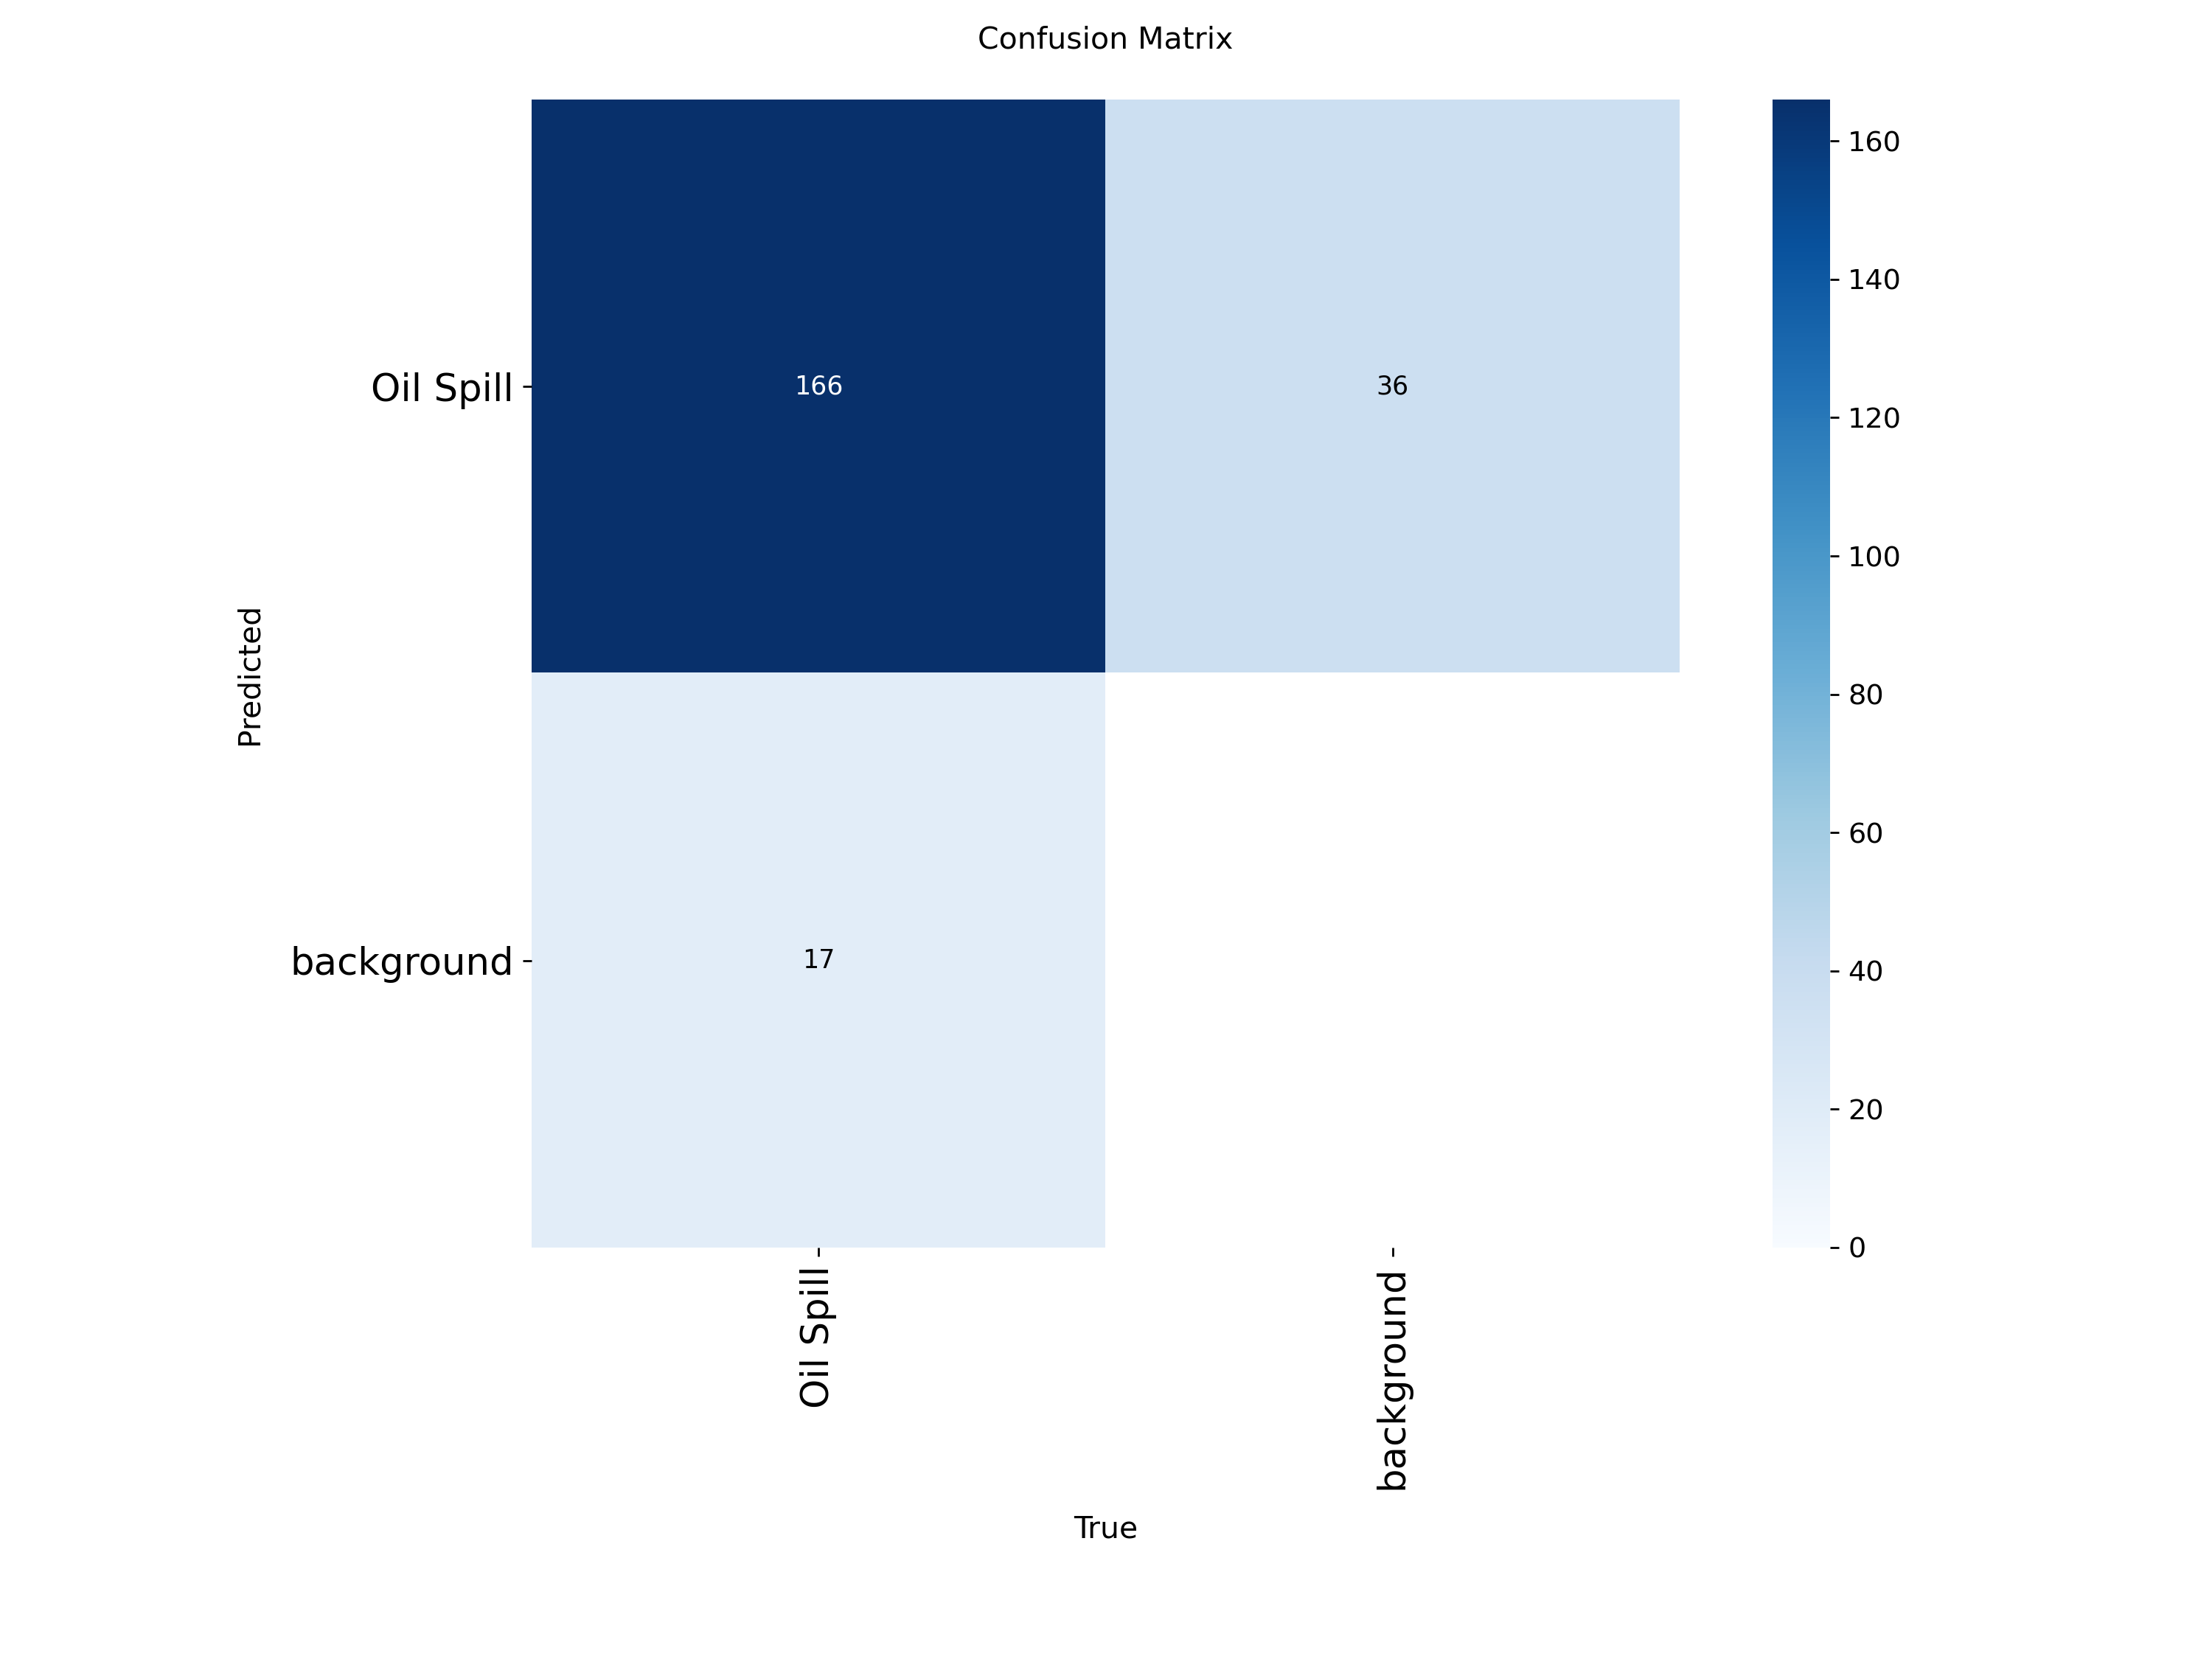

In [ ]:
from ultralytics import YOLO
import os

# 1. Load the uploaded model
model = YOLO(UPLOADED_WEIGHTS)

# 2. Run validation on the Roboflow dataset
# This automatically generates confusion_matrix.png, F1_curve.png, PR_curve.png, etc.
results = model.val(
    data='/content/Oil-2/data.yaml',
    split='test',
    imgsz=640,
    batch=16,
    name='roboflow_evaluation'
)

print("\n" + "="*50)
print("Validation Complete!")
print(f"Results saved to: {results.save_dir}")
print("="*50)

# Display the confusion matrix
from IPython.display import Image, display
cm_path = os.path.join(results.save_dir, 'confusion_matrix.png')
if os.path.exists(cm_path):
    print("\nConfusion Matrix:")
    display(Image(filename=cm_path))

In [ ]:
from IPython.display import Image, display
import os

# Define paths for common YOLO training curves
results_dir = results.save_dir

curves = [
    'results.png',      # Training/Validation losses and metrics
    'F1_curve.png',     # F1 Score vs Confidence
    'PR_curve.png',     # Precision-Recall curve
    'P_curve.png',      # Precision vs Confidence
    'R_curve.png'       # Recall vs Confidence
]

print(f"Displaying analysis curves from: {results_dir}")

for curve in curves:
    path = os.path.join(results_dir, curve)
    if os.path.exists(path):
        print(f"\n--- {curve} ---")
        display(Image(filename=path))
    else:
        # Check if they are in the root directory if uploaded manually
        if os.path.exists(curve):
            print(f"\n--- {curve} (from root) ---")
            display(Image(filename=curve))
        else:
            print(f"\nℹ️ {curve} not found. (This is normal if only weights were uploaded without the 'results.png' log file)")

Displaying analysis curves from: /content/runs/detect/roboflow_evaluation

ℹ️ results.png not found. (This is normal if only weights were uploaded without the 'results.png' log file)

ℹ️ F1_curve.png not found. (This is normal if only weights were uploaded without the 'results.png' log file)

ℹ️ PR_curve.png not found. (This is normal if only weights were uploaded without the 'results.png' log file)

ℹ️ P_curve.png not found. (This is normal if only weights were uploaded without the 'results.png' log file)

ℹ️ R_curve.png not found. (This is normal if only weights were uploaded without the 'results.png' log file)
